## Build PCCMA cell line metadata

The raw atlas records live in `raw_data/Rambutan_Atlasv2_April2026.xlsx`, a 14-sheet lab workbook:

- `Atlas conditions`: cell lines in the atlas with per-timepoint seeding densities and imaging QC notes. It is three stacked per-plate tables (plates 1-3), each with its own repeated header row.
- `Media`: growth media per cell line
- `Cell Density P1 & P2` / `Plate 3 Density+PlateMap`: day-of-seeding cell counts used to calculate seeding densities
- `PlateMap P1 & P2`: physical plate layout for plates 1-2 (not used here; the per-well sheets below are the authoritative source of well positions)
- `Plate-{1,2,3} {24,48,72}hr Metadata` (9 sheets): per-well records (plate barcode, row, column, density, coating)

Each "plate" (1, 2, 3) is a set of three physical plates, one per time point (24, 48, 72 hr), each with its own barcode.

Cell line names are **not spelled consistently across sheets and files** (e.g. `CHLA10` vs `CHLA-10` vs `CHLA -194`), so every join goes through a normalized key (uppercased, alphanumeric-only).

All inputs are in `raw_data/`, and the shared helper functions are in `utils/cell_line_utils.py`.

**Output:** `pccma_cell_line_metadata.csv` (plus `pccma_cell_line_metadata_columns.txt`, a description of every column). Only cell lines that were actually imaged in the atlas are included. There is one row per cell line, except `U2-OS`, which was run under several plate conditions on several plates: it gets one row per condition per plate (each with its own plate IDs and wells).

Annotation (cancer type, sex, age, subtype, source, origin, phase of disease) is consolidated into single columns from five sources on disk (the order of precedence for each column is given in step 10):

1. [`raw_data/pedmap_all_cell_lines_master.csv`](raw_data/pedmap_all_cell_lines_master.csv) - this lab's curated PedMap master sheet
2. [`raw_data/pccma_cog_prioritization_list.csv`](raw_data/pccma_cog_prioritization_list.csv) - this lab's COG tranche prioritization list
3. [`raw_data/cog_repository_metadata.csv`](raw_data/cog_repository_metadata.csv) - a snapshot of what the Childhood Cancer Repository (cccells.org) and Cellosaurus say about the COG lines (links, plus sex, age, subtype and origin). For those four fields its Cellosaurus and data-sheet values take precedence over the other sources
4. [`raw_data/Model_depmap_downloaded_2025-12-03.csv`](raw_data/Model_depmap_downloaded_2025-12-03.csv) - a DepMap `Model.csv` export (downloaded 2025-12-03; the release name is not recorded in the file)
5. [`raw_data/phase_of_disease_evidence.csv`](raw_data/phase_of_disease_evidence.csv) - phase of disease (at diagnosis vs relapse) where the repository catalog, the PPTP paper or the repository's Ewing panel record it

A few lines are in none of these and are resolved with a small, explicitly documented lookup (see step 10). Nothing is guessed: anything without a source is left empty.

In [1]:
import pathlib
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "utils")
from cell_line_utils import (  # noqa: E402
    clean_text,
    first_valid,
    indent,
    merge_one_to_one,
    normalize_name,
    phase_family,
    resolve_row,
)

RAW_DIR = pathlib.Path("raw_data")

/Users/waygr/miniconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Helpers

Shared helpers are imported from `utils/cell_line_utils.py`:

- `normalize_name` builds the join key: strips everything but letters/digits and uppercases, so `CHLA-10`, `CHLA10`, and `CHLA_10` collapse to one key.
- `merge_one_to_one` is a left join that fails loudly if it ever changes the number of rows.
- `first_valid` returns the first value that is not missing, used to combine sources in priority order.
- `clean_text` keeps text plain: it drops trademark symbols, straightens dashes and quotes, and joins line breaks.

### 1. `Atlas conditions` -> one row per cell line per plate condition

The sheet is three stacked per-plate tables, each re-declaring its header row. We split on those repeated header rows and
tag each block with its plate number (block 1 = plate 1, and so on). The header of blocks 2 and 3 lacks the last two
column names, so column names always come from the first block.

Every cell line appears once, except the `U2-OS` control, which appears under several coatings on each plate.
`coating_key` (the coating with any "w/ double PFA fixation" note removed) is used later to match rows to the
per-well sheets.

In [2]:
xlsx_path = RAW_DIR / "Rambutan_Atlasv2_April2026.xlsx"
xl = pd.ExcelFile(xlsx_path)

raw = (
    xl.parse("Atlas conditions", header=None)
    .dropna(how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)
header_row_idxs = raw.index[raw[0] == "Cell Line"].tolist()
canonical_cols = list(raw.iloc[header_row_idxs[0]])

blocks = []
for i, start in enumerate(header_row_idxs):
    end = header_row_idxs[i + 1] if i + 1 < len(header_row_idxs) else len(raw)
    block = raw.iloc[start + 1 : end].copy()
    block.columns = canonical_cols
    block["plate_number"] = str(i + 1)
    blocks.append(block)

atlas_df = (
    pd.concat(blocks, ignore_index=True)
    .dropna(subset=["Cell Line"])
    .rename(
        columns={
            "Cell Line": "cell_line",
            "Density for 24 hours": "seeding_density_24hr",
            "Density for 48 hours": "seeding_density_48hr",
            "Density for 72 hours": "seeding_density_72hr",
            "Plate conditions": "plate_conditions",
            "Comments": "qc_notes",
        }
    )
)
atlas_df["cell_line_key"] = atlas_df["cell_line"].map(normalize_name)
atlas_df["coating_key"] = (
    atlas_df["plate_conditions"].str.replace(r"\s*w/.*$", "", regex=True).str.strip().str.lower()
)
density_cols = ["seeding_density_24hr", "seeding_density_48hr", "seeding_density_72hr"]
atlas_df[density_cols] = atlas_df[density_cols].apply(pd.to_numeric, errors="coerce")
atlas_df = atlas_df[
    ["cell_line_key", "cell_line", "plate_number", "plate_conditions", "coating_key", *density_cols, "qc_notes"]
].reset_index(drop=True)

assert not atlas_df.duplicated(["cell_line_key", "plate_number", "coating_key"]).any()
print("Atlas conditions rows:", atlas_df.shape[0], "| unique cell lines:", atlas_df["cell_line_key"].nunique())
atlas_df[atlas_df["cell_line_key"] == "U2OS"][["cell_line", "plate_number", "plate_conditions"]]

Atlas conditions rows: 66 | unique cell lines: 60


,cell_line,plate_number,plate_conditions
13,U2-OS,1,Standard
32,U2-OS,2,Standard
33,U2-OS,2,Synthemax
34,U2-OS,2,Laminin
63,U2-OS,3,Standard
64,U2-OS,3,Laminin w/ double PFA fixation
65,U2-OS,3,Synthemax w/ double PFA fixation


### 2. `Media` sheet -> growth media

In [3]:
media_df = xl.parse("Media", header=0).dropna(how="all")
media_df = media_df.rename(columns={"Cell Line": "cell_line_raw", "Media": "media_formulation"})
media_df["cell_line_key"] = media_df["cell_line_raw"].map(normalize_name)
media_df["cell_line_key"] = media_df["cell_line_key"].replace({"D283MED": "D283"})  # sheet says "D283 Med"
media_df = media_df.drop_duplicates(subset="cell_line_key", keep="first")[["cell_line_key", "media_formulation"]]
media_df["media_formulation"] = media_df["media_formulation"].map(clean_text).str.replace(r"(?<= )\+(?=\S)", "+ ", regex=True)

master = merge_one_to_one(atlas_df, media_df, on="cell_line_key")
master.shape

(66, 10)

### 3. Per-well metadata -> plate IDs and wells; keep only cell lines actually imaged

The 9 `Plate-{1,2,3} {24,48,72}hr Metadata` sheets list every well. We drop the empty `media` wells and, for each cell line
on each plate under each coating, collect:

- `plate_ids`: the plate barcodes, pipe-separated, ordered by time point (24 hr | 48 hr | 72 hr)
- `wells`: the wells, pipe-separated (row letter + two-digit column, e.g. `B02`, matching the platemap files in
  `0.download_data/metadata/platemaps/`). The same wells are used on all three time-point plates (asserted below),
  so this list applies to every barcode in `plate_ids`.

Rows in `Atlas conditions` with no wells in these sheets were planned but never imaged; they are dropped so that the
table contains only cell lines in the atlas.

In [4]:
meta_records = []
for sheet in [s for s in xl.sheet_names if "Metadata" in s]:
    df = xl.parse(sheet, header=0).dropna(how="all").dropna(subset=["Cell Line"])
    df = df[df["Cell Line"].astype(str).str.strip().str.lower() != "media"].copy()
    df["plate_number"] = re.search(r"Plate-(\d+)", sheet).group(1)
    meta_records.append(df)

wells_df = pd.concat(meta_records, ignore_index=True)
wells_df["cell_line_key"] = wells_df["Cell Line"].map(normalize_name)
wells_df["coating_key"] = wells_df["Plate Coating"].astype(str).str.strip().str.lower()
wells_df["well"] = wells_df["Row"].astype(str).str.strip() + wells_df["Column"].astype(float).astype(int).astype(str).str.zfill(2)
assert not wells_df.duplicated(["Plate Barcode", "well"]).any()

records = []
for (key, plate, coating), group in wells_df.groupby(["cell_line_key", "plate_number", "coating_key"]):
    wells_per_barcode = group.groupby("Plate Barcode")["well"].agg(lambda x: tuple(sorted(x)))
    assert wells_per_barcode.nunique() == 1, f"wells differ across time-point plates for {key}"
    barcodes = group.sort_values("Time Point (hours)")["Plate Barcode"].drop_duplicates().tolist()
    records.append(
        {
            "cell_line_key": key,
            "plate_number": plate,
            "coating_key": coating,
            "plate_ids": "|".join(barcodes),
            "wells": "|".join(wells_per_barcode.iloc[0]),
        }
    )
well_summary = pd.DataFrame(records)

master = master.merge(well_summary, on=["cell_line_key", "plate_number", "coating_key"], how="left")
not_imaged = master[master["wells"].isna()]
print("Planned in Atlas conditions but never imaged (dropped):", sorted(not_imaged["cell_line"].unique()))

master = master[master["wells"].notna()].reset_index(drop=True)
assert len(master) == len(well_summary), "every imaged well group should match exactly one Atlas conditions row"
print("Imaged rows:", len(master), "| imaged cell lines:", master["cell_line_key"].nunique())
master[["cell_line", "plate_number", "plate_conditions", "plate_ids", "wells"]].head(4)

Planned in Atlas conditions but never imaged (dropped): ['ATRT310', 'ATRT311 FHTC', 'EPD210 FHTC', 'PBT05FHTC']
Imaged rows: 62 | imaged cell lines: 56


,cell_line,plate_number,plate_conditions,plate_ids,wells
0,DAOY,1,Standard,BR00150695|BR00150696|BR00150697,C03|C04|D03|D04
1,G292,1,Standard,BR00150695|BR00150696|BR00150697,E03|E04|F03|F04
2,G401,1,Standard,BR00150695|BR00150696|BR00150697,G03|G04|H03|H04
3,G402,1,Standard,BR00150695|BR00150696|BR00150697,I03|I04|J03|J04


#### Data-quality check: per-well seeding density vs `Atlas conditions`

`seeding_density_*` in the output are the values recorded on the `Atlas conditions` sheet, unmodified. The per-well sheets
also record the density actually plated in each well. Any disagreement between the two is listed here for review; nothing
is changed automatically.

In [5]:
recorded = (
    wells_df.groupby(["cell_line_key", "plate_number", "coating_key", "Time Point (hours)"])["Density (cells/well)"]
    .agg(lambda x: sorted(set(x.dropna())))
    .reset_index()
)
flags = []
for _, r in recorded.iterrows():
    match = master[
        (master["cell_line_key"] == r["cell_line_key"])
        & (master["plate_number"] == r["plate_number"])
        & (master["coating_key"] == r["coating_key"])
    ].iloc[0]
    column = f"seeding_density_{int(r['Time Point (hours)'])}hr"
    if r["Density (cells/well)"] != [match[column]]:
        flags.append(
            {
                "cell_line": match["cell_line"],
                "plate_number": r["plate_number"],
                "column": column,
                "atlas_conditions_sheet": match[column],
                "per_well_sheets": r["Density (cells/well)"],
            }
        )
density_flags = pd.DataFrame(flags)
print(len(density_flags), "disagreements")
density_flags

5 disagreements


,cell_line,plate_number,column,atlas_conditions_sheet,per_well_sheets
0,ONS-76,1,seeding_density_24hr,8000,"[8000.0, 12000.0]"
1,PA1,1,seeding_density_24hr,4000,"[4000.0, 8000.0]"
2,RH30,2,seeding_density_48hr,120000,[12000.0]
3,Saos-2,1,seeding_density_24hr,8000,"[4000.0, 8000.0]"
4,SK-N-AS,1,seeding_density_24hr,12000,"[8000.0, 12000.0]"


### 4. Density sheets -> cell count at seeding

`Cell Count` on the `Cell Density P1 & P2` / `Plate 3 Density+PlateMap` sheets is the cell count of the harvested stock
suspension on the day of seeding (2026-05-15 for plates 1-2, 2026-05-29 for plate 3). The sheets do not state units, but
`cell slurry` equals `Density in 1ml` / `Cell Count` exactly in every row, so it is in the same cells/mL units as
`Density in 1ml`. Because the count is specific to a seeding day, it is matched on cell line **and plate number**
(this matters for `U2-OS`, which has a different count for plates 1-2 and plate 3).

In [6]:
count_records = []
for sheet, plate_numbers in [("Cell Density P1 & P2", ["1", "2"]), ("Plate 3 Density+PlateMap", ["3"])]:
    raw_d = xl.parse(sheet, header=None).dropna(how="all").dropna(axis=1, how="all").reset_index(drop=True)
    hdr_idx = raw_d.index[raw_d[0] == "Cell Line"][0]
    df = raw_d.iloc[hdr_idx + 1 :].copy()
    df.columns = raw_d.iloc[hdr_idx]
    df = df.dropna(subset=["Cell Line"])[["Cell Line", "Cell Count"]]
    for plate_number in plate_numbers:
        count_records.append(df.assign(plate_number=plate_number))

counts = pd.concat(count_records, ignore_index=True)
counts["cell_line_key"] = counts["Cell Line"].map(normalize_name)
counts["cell_count_at_seeding"] = pd.to_numeric(counts["Cell Count"], errors="coerce")
counts = counts.dropna(subset=["cell_count_at_seeding"])
assert (counts.groupby(["cell_line_key", "plate_number"])["cell_count_at_seeding"].nunique() == 1).all()
counts = counts.drop_duplicates(["cell_line_key", "plate_number"])[["cell_line_key", "plate_number", "cell_count_at_seeding"]]

master = merge_one_to_one(master, counts, on=["cell_line_key", "plate_number"])
print("Rows with a recorded cell count:", master["cell_count_at_seeding"].notna().sum(), "/", len(master))

Rows with a recorded cell count: 60 / 62


### 5. COG prioritization list

Pediatric patient-derived (CHLA-/COG-) lines. Only the fields that feed the consolidated columns are kept.

In [7]:
cog_df = pd.read_csv(RAW_DIR / "pccma_cog_prioritization_list.csv")
cog_df["cell_line_key"] = cog_df["Cell Line"].map(normalize_name)
cog_sub = (
    cog_df[["cell_line_key", "Cancer Type", "Age"]]
    .rename(columns={"Cancer Type": "cancer_type_cog", "Age": "age_cog"})
    .drop_duplicates(subset="cell_line_key", keep="first")
)
master = merge_one_to_one(master, cog_sub, on="cell_line_key")
master["in_cog_list"] = master["cell_line_key"].isin(cog_sub["cell_line_key"])
print("Cell lines matched to COG list:", master.drop_duplicates("cell_line_key")["cancer_type_cog"].notna().sum())

Cell lines matched to COG list: 20


### 6. DepMap

Standard/commercial cancer cell lines. Two names carry extra text in DepMap (`"G-292, clone A141B1"`, `"D283 Med"`) that
survives normalization, so they are mapped with an explicit alias table. DepMap's vocabulary is harmonized with the
lab's: `Metastatic` becomes `Metastasis`, `Unknown` sex/origin becomes empty, and `Recurrent` (not an anatomical origin) is left empty. `PatientTreatmentStatus` is
mapped to phase-of-disease codes (`Pre-treatment` = `Dx`, `Post-treatment` (relapse) = `PD`, `Active treatment` unchanged); DepMap
records it for very few models. DepMap's source (`SourceDetail`) falls back to `SourceType` when empty.

In [8]:
depmap_df = pd.read_csv(RAW_DIR / "Model_depmap_downloaded_2025-12-03.csv")
depmap_df["cell_line_key"] = depmap_df["StrippedCellLineName"].map(normalize_name)
depmap_df["SourceDetail"] = depmap_df["SourceDetail"].fillna(depmap_df["SourceType"])

depmap_alias_overrides = {
    "G292": "G292CLONEA141B1",
    "D283": "D283MED",
}
depmap_sub = (
    depmap_df[["cell_line_key", "ModelID", "OncotreePrimaryDisease", "Age", "Sex", "PrimaryOrMetastasis", "SourceDetail", "PatientTreatmentStatus"]]
    .rename(
        columns={
            "cell_line_key": "_depmap_lookup_key",
            "ModelID": "depmap_id",
            "OncotreePrimaryDisease": "cancer_type_depmap",
            "Age": "age_depmap",
            "Sex": "sex_depmap",
            "PrimaryOrMetastasis": "origin_depmap",
            "SourceDetail": "source_depmap",
            "PatientTreatmentStatus": "phase_depmap",
        }
    )
    .drop_duplicates(subset="_depmap_lookup_key", keep="first")
)
master["_depmap_lookup_key"] = master["cell_line_key"].replace(depmap_alias_overrides)
master = merge_one_to_one(master, depmap_sub, on="_depmap_lookup_key").drop(columns="_depmap_lookup_key")

master["sex_depmap"] = master["sex_depmap"].where(master["sex_depmap"].isin(["Male", "Female"]))
master["origin_depmap"] = master["origin_depmap"].map({"Primary": "Primary", "Metastatic": "Metastasis"})
master["phase_depmap"] = master["phase_depmap"].map({"Pre-treatment": "Dx", "Post-treatment": "PD", "Active treatment": "Active treatment"})
print("Cell lines matched to DepMap:", master.drop_duplicates("cell_line_key")["depmap_id"].notna().sum())

Cell lines matched to DepMap: 32


### 7. PedMap master sheet

The lab's own curated sheet. A few names differ from the atlas workbook, so a small explicit alias table maps them
(keys are normalized names):

- `ATRT-310FHTC` -> `ATRT310`, `G-292,CLONE A141B1` -> `G292`, `D283 Med` -> `D283` (the atlas workbook uses shorter names)
- `Rh 41 (Rh4)` -> `RH41` and `RH4 (RH41)` -> `RH4` (the sheet lists the two alveolar rhabdomyosarcoma lines with each
  other's name in parentheses; the COG-sourced entry is treated as `RH41`, the Koehler Lab entry as `RH4`)

PedMap rows for lines that are not in the atlas are ignored. The source text `St. Jude Research Institute` is shortened to
`St. Jude`, and the leading `Approx.` / `approximately` is dropped from the observed doubling times (the column name says it is approximate). The BTRL rows in the sheet have a malformed URL prefix
(`https:/btrl.org`, one slash), which is corrected. Link accuracy was checked separately (ATCC pages match their cell
line; HSRRB catalog numbers match Cellosaurus; `btrl.org` redirects to the Seattle Children's Brain Tumor Resource Lab).

In [9]:
pedmap_df = pd.read_csv(RAW_DIR / "pedmap_all_cell_lines_master.csv").rename(columns={"Unnamed: 0": "depmap_id_pedmap"})
pedmap_df["cell_line_key"] = pedmap_df["cell_line"].map(normalize_name)

pedmap_key_overrides = {
    "ATRT310FHTC": "ATRT310",
    "G292CLONEA141B1": "G292",
    "D283MED": "D283",
    "RH41RH4": "RH41",
    "RH4RH41": "RH4",
}
pedmap_df["cell_line_key"] = pedmap_df["cell_line_key"].replace(pedmap_key_overrides)
assert pedmap_df["cell_line_key"].is_unique

pedmap_sub = pedmap_df[
    [
        "cell_line_key",
        "depmap_id_pedmap",
        "cancer_type",
        "sex",
        "age",
        "subtype",
        "source",
        "origin",
        "Doubling Time (5% CO2) (Observed)",
        "Cell Line link",
    ]
].rename(
    columns={
        "cancer_type": "cancer_type_pedmap",
        "sex": "sex_pedmap",
        "age": "age_pedmap",
        "subtype": "subtype_pedmap",
        "source": "source_pedmap",
        "origin": "origin_pedmap",
        "Doubling Time (5% CO2) (Observed)": "doubling_time_observed_pedmap",
        "Cell Line link": "cell_line_link_pedmap",
    }
)
pedmap_sub["age_pedmap"] = pd.to_numeric(pedmap_sub["age_pedmap"], errors="coerce")
pedmap_sub["source_pedmap"] = pedmap_sub["source_pedmap"].str.replace("St. Jude Research Institute", "St. Jude", regex=False)
pedmap_sub["doubling_time_observed_pedmap"] = (
    pedmap_sub["doubling_time_observed_pedmap"]
    .str.replace(r"^\s*(?:approximately|approx\.?)\s*", "", case=False, regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
pedmap_sub["cell_line_link_pedmap"] = pedmap_sub["cell_line_link_pedmap"].str.replace(r"^https:/(?!/)", "https://", regex=True)

master = merge_one_to_one(master, pedmap_sub, on="cell_line_key")
in_atlas = set(master["cell_line_key"])
print("Cell lines matched to PedMap:", master.drop_duplicates("cell_line_key")["cancer_type_pedmap"].notna().sum())
print("PedMap rows not in the atlas:", sorted(pedmap_df.loc[~pedmap_df["cell_line_key"].isin(in_atlas), "cell_line"]))

both = master.drop_duplicates("cell_line_key").dropna(subset=["depmap_id", "depmap_id_pedmap"])
disagree = both[both["depmap_id"] != both["depmap_id_pedmap"]]
print("DepMap ID disagreements between the DepMap join and PedMap:", len(disagree))
master["depmap_id"] = master["depmap_id"].fillna(master["depmap_id_pedmap"])

Cell lines matched to PedMap: 44
PedMap rows not in the atlas: ['ATRT-310FHTC', 'ATRT-311FHTC', 'Astro-111FHTC', 'D341 Med', 'EPD-210FHTC', 'GBM-109FHTC', 'GBM-110FHTC', 'GBM-511FHTC', 'HDMB03', 'MB002', 'PBT-05FHTC']
DepMap ID disagreements between the DepMap join and PedMap: 0


### 8. Childhood Cancer Repository + Cellosaurus snapshot (COG lines)

`raw_data/cog_repository_metadata.csv` is a snapshot (retrieved 2026-09-23) of what public sources say about the COG lines.
Each value sits in a column named for its source, so nothing is merged silently:

- **Cellosaurus** ([cellosaurus.org](https://www.cellosaurus.org); `*_cellosaurus` columns): sex, age, gene fusion, and the
  derived-from site (`cellosaurus_derived_from_site`). It has entries for 10 of the 20 COG lines.
- **Repository data sheets** (`*_data_sheet` columns): per-line PDFs from the
  [Childhood Cancer Repository](https://cccells.org), published only for `CHLA-200`, `CHLA-25`, `Rh41`, `SJ-GBM2` and
  `TC-71`. `COG-E-352` also has one, but only in an Internet Archive capture (2016) of the old cogcell.org site
  (`archived_data_sheet_url`); it is treated the same way.
- **Repository catalog tables** (`*_catalog_table` columns): the repository's disease tables (age, EWS/FLI1 status), with
  the raw specimen type in `sample_type_catalog_table`.
- **STR database** ([strdb.cccells.org](https://strdb.cccells.org); `amelogenin_str`, `sex_str`): the repository's STR
  profiles include the Amelogenin (sex chromosome) call. Only a **Y allele** is used as evidence of sex (`sex_str` = Male).
  Checked on 2026-09-23 against every atlas line with a known sex: `X,Y` was male in 7 of 7, but `X`-only or `X,X` calls
  occurred in 4 of 17 known-male lines (Y is lost in culture), so an X-only call is not evidence of female sex.
- **Specimen-type inference** (`origin_inferred_from_specimen`, weakest evidence): a body-fluid specimen from a solid-tumor
  patient (`cerebrospinal fluid`, `peritoneal fluid`) is disseminated disease, so `Metastasis`. A specimen taken from the eye in retinoblastoma (`CHLA-196` and `CHLA-210`,
  both `(from left eye)`) is `Primary`: retinoblastoma arises in the eye and cannot metastasize into it, so an eye specimen
  is from the primary tumor site (a relapse there is still `Primary`, see the `origin` column). A bare `tumor`,
  `tumor (autopsy)` or `tumor, (relapse)` gives no call. Every COG line in the catalog is a post-treatment specimen
  (PD, PD-BMT, PD-PM), so the phase of disease alone says nothing about primary vs metastasis.

Within the snapshot the order of precedence is **Cellosaurus > data sheet > catalog table**, with STR and specimen-type
inference last. For `sex`, `age`, `subtype` and `origin` the snapshot's Cellosaurus and data-sheet values also take
precedence over PedMap, the COG list and DepMap (see step 10). `CHLA262` is not listed by the repository, Cellosaurus or the
STR database under that name, so it has no entry.

Other public sources were checked and hold nothing further for the remaining lines: older captures of the repository's
catalog tables (Gender and Age columns existed only for `CHLA-200` and `SJ-GBM2`), the repository's journal-citation list,
and full-text literature search (Europe PMC), where most of these lines are never mentioned by name. Age is the least
recoverable field: no public source states it for the remaining lines, so it would have to come from COG's own per-line
records.

- **Links:** the line's data-sheet PDF when one exists, otherwise the repository catalog page that lists the line (a disease
  table, not a per-line page). All were checked to return the right content type.
- **Corrected data-sheet errors:** the `TC-71` data sheet lists its EWS/FLI1 status as ERG and the `CHLA-25` sheet lists FLI1.
  Cellosaurus (citing PubMed), the catalog table and the archived catalog tables all say the opposite (`TC-71` = EWSR1-FLI1,
  `CHLA-25` = EWSR1-ERG), so the `*_data_sheet` columns hold the corrected values and `notes` records the correction.
- **Subtype:** Ewing-family fusion partner as `EWS_FLI` / `EWS_ERG` (PedMap's naming) and `PAX3_FOXO1` for `Rh41`. The data
  sheet only says "PAX-FKHR positive" without naming PAX3 or PAX7, so its own column is left empty.
- **Origin:** Cellosaurus `Metastatic` becomes `Metastasis` and `In situ` becomes `Primary`, except `COG-E-352`, whose
  Cellosaurus site (`In situ; Peripheral blood`) does not indicate primary vs metastasis. Its archived data sheet lists the
  culture source as blood (post-mortem) and the primary tumor site as fibula, so the specimen is not from the primary site
  and it is recorded as `Metastasis`.
- **Age:** Cellosaurus and the data sheets are converted to years (for example `2Y7M` = 2.6). Where Cellosaurus only says
  `Children`, there is no age.

Two checks follow: disagreements among the snapshot's own sources, and the values where the snapshot replaces a different
value from PedMap, the COG list or DepMap.

In [10]:
repo_df = pd.read_csv(RAW_DIR / "cog_repository_metadata.csv")
repo_df["cell_line_key"] = repo_df["cell_line"].map(normalize_name)
assert repo_df["cell_line_key"].is_unique
repo_df["cell_line_link_repository"] = repo_df["data_sheet_url"].fillna(repo_df["catalog_table_url"])

# Within the snapshot: Cellosaurus first, then the repository data sheet
for field in ["sex", "age", "subtype", "origin"]:
    sources = [c for c in (f"{field}_cellosaurus", f"{field}_data_sheet") if c in repo_df.columns]
    repo_df[f"{field}_snapshot"] = repo_df[sources].bfill(axis=1).iloc[:, 0]
repo_df = repo_df.rename(
    columns={
        "age_catalog_table": "age_catalog",
        "subtype_catalog_table": "subtype_catalog",
        "origin_catalog_table": "origin_catalog",
        "origin_inferred_from_specimen": "origin_inferred",
    }
)

disagreements = []
for field in ["sex", "age", "subtype", "origin"]:
    sources = [c for c in repo_df.columns if c.startswith(f"{field}_") and c.rsplit("_", 1)[-1] in ("cellosaurus", "sheet", "catalog", "str", "inferred")]
    for _, row in repo_df.iterrows():
        values = {c: row[c] for c in sources if pd.notna(row[c])}
        if len(set(values.values())) > 1:
            disagreements.append({"cell_line": row["cell_line"], "field": field, **values})
print("Disagreements among the snapshot's own sources (Cellosaurus is used, then the data sheet):")
print(pd.DataFrame(disagreements).to_string(index=False) if disagreements else "none")

snapshot_columns = [
    "cell_line_key", "cell_line_link_repository",
    "sex_snapshot", "age_snapshot", "subtype_snapshot", "origin_snapshot",
    "age_catalog", "subtype_catalog", "origin_catalog",
    "sex_str", "origin_inferred",
]
master = merge_one_to_one(master, repo_df[snapshot_columns], on="cell_line_key")

lines = master.drop_duplicates("cell_line_key")
print("\nCell lines with a repository record:", lines["cell_line_link_repository"].notna().sum())
cog_sourced = (lines["source_pedmap"] == "COG") | (lines["source_pedmap"].isna() & lines["in_cog_list"])
print("COG-sourced lines with no repository record:", lines.loc[cog_sourced & lines["cell_line_link_repository"].isna(), "cell_line"].tolist())

other_sources = pd.DataFrame(
    {
        "cell_line": lines["cell_line"],
        "sex": lines["sex_pedmap"].fillna(lines["sex_depmap"]),
        "age": pd.to_numeric(lines["age_pedmap"]).fillna(pd.to_numeric(lines["age_cog"])).fillna(pd.to_numeric(lines["age_depmap"])),
        "origin": lines["origin_pedmap"].fillna(lines["origin_depmap"]),
    }
)
replaced = []
for column in ["sex", "age", "origin"]:
    snapshot_value = pd.to_numeric(lines[f"{column}_snapshot"]) if column == "age" else lines[f"{column}_snapshot"]
    both = snapshot_value.notna() & other_sources[column].notna()
    differs = (snapshot_value - other_sources[column]).abs() > 0.05 if column == "age" else snapshot_value != other_sources[column]
    for idx in lines.index[both & differs]:
        replaced.append(
            {
                "cell_line": lines.loc[idx, "cell_line"],
                "column": column,
                "value used (snapshot)": snapshot_value[idx],
                "value replaced (PedMap / COG list / DepMap)": other_sources.loc[idx, column],
            }
        )
print(len(replaced), "values where the snapshot replaces a different PedMap / COG list / DepMap value:")
pd.DataFrame(replaced)

Disagreements among the snapshot's own sources (Cellosaurus is used, then the data sheet):
cell_line field  age_cellosaurus  age_data_sheet
   SJGBM2   age              6.0             4.2

Cell lines with a repository record: 19
COG-sourced lines with no repository record: ['CHLA262']
2 values where the snapshot replaces a different PedMap / COG list / DepMap value:


,cell_line,column,value used (snapshot),value replaced (PedMap / COG list / DepMap)
0,SJGBM2,age,6.0,5.0
1,CHLA25,age,2.6,2.0



### 9. Phase of disease

`phase_of_disease` records when in the patient's care the specimen was taken, in the Childhood Cancer Repository's codes:
`Dx` (before treatment), `PD` (progressive disease: relapse after chemotherapy), `PD-BMT` (relapse after chemotherapy and
bone marrow transplantation), `PD-PM` (post-mortem, relapsed) and `P-EBR` (used by the repository for `CHLA-210`; the site
does not define it). It is a different axis from `origin`, which is anatomical (primary site vs metastasis).

Sources, first available wins:

1. `raw_data/phase_of_disease_evidence.csv`, a snapshot (retrieved 2026-09-23) with one row per line and source:
   the repository catalog tables (every COG line except `CHLA262`, plus `RH30`); Table 1 of the PPTP paper
   ([Kang et al. 2011](https://pmc.ncbi.nlm.nih.gov/articles/PMC3005554/), PMID 20922763) for `RD`, `Rh30`, `Rh41`, `SJ-GBM2`,
   `CHLA-10`, `CHLA-258` and `TC-71`, whose codes are translated (DX = `Dx`, Post-Tx = relapse after chemotherapy = `PD`,
   Post-BMT = `PD-BMT`); and the repository's Ewing panel PDF for `SK-N-MC` (post-chemotherapy).
2. the `Phase of Therapy` column of the COG list.
3. DepMap `PatientTreatmentStatus`, where recorded.

Most non-COG lines (the standard commercial lines, the Brain Tumor Resource Lab lines, the cureMEC lines) have no public record
of phase, so they are empty. That is a gap in the sources, not a statement that the specimens were untreated. `CHLA262` has none
either. A check lists any line whose sources disagree about `Dx` vs relapse.

In [11]:

phase_evidence = pd.read_csv(RAW_DIR / "phase_of_disease_evidence.csv")
phase_evidence["cell_line_key"] = phase_evidence["cell_line"].map(normalize_name)
assert not phase_evidence.duplicated(["cell_line_key", "evidence_source"]).any()
evidence_order = ["Repository catalog table", "PPTP paper (Kang 2011) Table 1", "Repository Ewing panel PDF"]
phase_by_source = phase_evidence.pivot(index="cell_line_key", columns="evidence_source", values="phase_of_disease")

phase_table = (
    phase_by_source.reindex(columns=evidence_order)
    .join(cog_df.drop_duplicates("cell_line_key").set_index("cell_line_key")["Phase of Therapy"].rename("COG list"), how="outer")
    .join(master.drop_duplicates("cell_line_key").set_index("cell_line_key")["phase_depmap"].rename("DepMap"), how="outer")
    .reindex(master["cell_line_key"].unique())
)
master["phase_of_disease"] = master["cell_line_key"].map(phase_table.bfill(axis=1).iloc[:, 0])


conflicting = phase_table.apply(lambda column: column.map(phase_family)).nunique(axis=1) > 1
lines = master.drop_duplicates("cell_line_key")
print("Cell lines with a phase of disease:", lines["phase_of_disease"].notna().sum(), "of", len(lines))
print(lines["phase_of_disease"].value_counts().to_dict())
print("Lines whose sources disagree about Dx vs relapse:", phase_table.index[conflicting].tolist())


Cell lines with a phase of disease: 22 of 56
{'PD': 15, 'PD-PM': 3, 'PD-BMT': 2, 'Dx': 1, 'P-EBR': 1}
Lines whose sources disagree about Dx vs relapse: []


### 10. Consolidate into single columns; fill remaining gaps

For each of `cancer_type`, `sex`, `age`, `subtype`, `source` and `origin`, the value is the first one available in the
priority order **ATCC normal-line lookup > PedMap > COG list > DepMap > the other lookups below** for `cancer_type`. For `sex`, `age`, `subtype` and `origin` the order is
**Cellosaurus > repository data sheet** (both from the step 8 snapshot) **> PedMap > COG list** (age only) **> repository catalog table > DepMap >** the snapshot's weakest evidence (STR Amelogenin for `sex`, specimen type for `origin`). Columns are coalesced independently, so a line can
take its cancer type from one source and its age from another.

Lines missing from all three files are resolved with these explicit lookups:

- **ATCC normal (non-cancer) reference lines** used as imaging controls (`CCD 841 CoN`, `WI-38`, `HMC3`, `WPMY-1`).
  Catalog numbers and links were checked against the ATCC product pages (each page title names the right cell line). Their label takes precedence over DepMap's `Non-Cancerous`, and `origin` is left empty for them because they are not tumors. Their `sex` and `age` come from the same ATCC pages, cross-checked with Cellosaurus: CCD 841 CoN and WI-38 are female and WPMY-1 is male (54 years). CCD 841 CoN, WI-38 and HMC3 come from fetal tissue (21 weeks, 3 months and 8-10 weeks of gestation), so their age is recorded as 0 (a gestational age is not an age in years). HMC3's sex is unspecified in both sources, so it stays empty.
- **Derivative lines** (`CHP212-1020`, `CHP212-EV`, `SKNAS-1020`, `SKNAS-EV`). The `Media` sheet grows
  all four in puromycin, and their names suggest constructs / empty-vector controls of the parental lines, so they take the
  parent's tumor attributes (`cancer_type`, `sex`, `age`, `subtype`, `origin` and `phase_of_disease`). The parental line's source,
  link, DepMap ID and observed doubling time are not copied. This is inferred from naming and media, not from a source record.
- **cureMEC lines** `CF1500` and `X0092` are labeled `"Cure MEC Line #2"` and `"Cure MEC Line #1"` in this lab's plate maps
  (`0.download_data/metadata/platemaps/Assay_Plate9_platemap.csv`). [cureMEC.org](https://www.curemec.org) states MEC =
  Myoepithelial Carcinoma, an ultra-rare cancer.
- **`CHP134`** is in neither PedMap nor the repository. DepMap gives its source as Sigma-Aldrich (ECACC 06122002, per
  Cellosaurus), but Sigma's catalog page could not be verified, so `cell_line_link` points to the DSMZ catalog entry for the
  same line (`ACC-653`, also cross-referenced by Cellosaurus), which resolves and names `CHP-134`. `source` stays as DepMap gives it.
- **`RH30`**: the repository's rhabdomyosarcoma catalog lists Rh30 with a data sheet (alveolar, male, 17 years at diagnosis,
  bone marrow, phase Dx, all consistent with this table), but PedMap has no link for it and gives its source as Koehler Lab/MIT.
  `cell_line_link` points to the repository's Rh30 data sheet; `source` stays as PedMap gives it.
- **COG lines with no other recorded source** (e.g. `COGW408`) get `source = COG`, since the COG prioritization list is
  a list of COG cell lines.
- **Molecular subtype** for the Seattle Children's
  [Brain Tumor Resource Lab](https://www.seattlechildrens.org/research/centers-programs/childhood-cancer/our-labs/jim-olson-lab/btrl/)
  lines (`ATRT310`, `ATRT311 FHTC`, `EPD210 FHTC`, `PBT04 FHTC`, `PBT05FHTC`) comes from their public catalog when PedMap
  has none.

In [12]:
# Sex and age come from the ATCC product pages, cross-checked against Cellosaurus (CVCL_2871, CVCL_0579, CVCL_II76, CVCL_3814).
# CCD 841 CoN (21 weeks of gestation), WI-38 (3 months) and HMC3 (embryo, 8-10 weeks) are fetal-derived: they have only a
# gestational age, so their age in years is recorded as 0. HMC3's sex is unspecified in both sources (None).
normal_reference_lines = {
    "CCD841CON": {"cancer_type": "Normal (colon epithelium)", "sex": "Female", "age": 0, "source": "ATCC CRL-1790", "link": "https://www.atcc.org/products/crl-1790"},
    "WI38": {"cancer_type": "Normal (embryonic lung fibroblast)", "sex": "Female", "age": 0, "source": "ATCC CCL-75", "link": "https://www.atcc.org/products/ccl-75"},
    "HMC3": {"cancer_type": "Normal (immortalized microglia)", "sex": None, "age": 0, "source": "ATCC CRL-3304", "link": "https://www.atcc.org/products/crl-3304"},
    "WPMY1": {"cancer_type": "Normal (prostate stromal myofibroblast)", "sex": "Male", "age": 54, "source": "ATCC CRL-2854", "link": "https://www.atcc.org/products/crl-2854"},
}
derivative_lines = {
    "CHP2121020": {"parent_key": "CHP212", "parent_name": "CHP-212"},
    "CHP212EV": {"parent_key": "CHP212", "parent_name": "CHP-212"},
    "SKNAS1020": {"parent_key": "SKNAS", "parent_name": "SK-N-AS"},
    "SKNASEV": {"parent_key": "SKNAS", "parent_name": "SK-N-AS"},
}
published_lookup_lines = {
    "ATRT310": {"subtype": "SHH subgroup (SMARCB1-mutant)"},
    "ATRT311FHTC": {"subtype": "SHH subgroup (SMARCB1-mutant)"},
    "EPD210FHTC": {"subtype": "PFA subgroup (posterior fossa group A, 1q gain)"},
    "PBT04FHTC": {"subtype": "MYCN/ID2 amplified"},
    "PBT05FHTC": {"subtype": "MYCN-driven"},
    "CF1500": {"cancer_type": "Myoepithelial Carcinoma (MEC)", "source": "cureMEC (Cure MEC Line #2)"},
    "X0092": {"cancer_type": "Myoepithelial Carcinoma (MEC)", "source": "cureMEC (Cure MEC Line #1)"},
    "CHP134": {"link": "https://www.dsmz.de/collection/catalogue/details/culture/ACC-653"},
    "RH30": {"link": "https://www.cccells.org/PDF_Files/Rhabdomyosarcoma/Rh30%20Cell%20Line%20Data%20Sheet.pdf"},
}

parent_lookup = master.drop_duplicates("cell_line_key").set_index("cell_line_key")[
    ["cancer_type_pedmap", "cancer_type_cog", "cancer_type_depmap"]
]


consolidated = master.apply(
    resolve_row, axis=1, args=(normal_reference_lines, published_lookup_lines, derivative_lines, parent_lookup)
)
consolidated["age"] = pd.to_numeric(consolidated["age"], errors="coerce")
master = pd.concat([master, consolidated], axis=1)

# Derivative lines take the tumor attributes of their parental line
inherited_columns = ["sex", "age", "subtype", "origin", "phase_of_disease"]
parent_values = master.drop_duplicates("cell_line_key").set_index("cell_line_key")[inherited_columns]
for key, derivative in derivative_lines.items():
    rows = master["cell_line_key"] == key
    for column in inherited_columns:
        master.loc[rows, column] = master.loc[rows, column].fillna(parent_values.loc[derivative["parent_key"], column])

lines = master.drop_duplicates("cell_line_key")
print("Cell lines with no cancer type:", lines.loc[lines["cancer_type"].isna(), "cell_line"].tolist())
print("Missing per consolidated column (cell lines):")
lines[["cancer_type", "sex", "age", "subtype", "source", "origin", "phase_of_disease", "depmap_id"]].isna().sum()

Cell lines with no cancer type: []
Missing per consolidated column (cell lines):


cancer_type          0
sex                 13
age                 15
subtype             36
source               0
origin              14
phase_of_disease    34
depmap_id           24
dtype: int64

### 11. Sanity-check plots (one point per cell line)

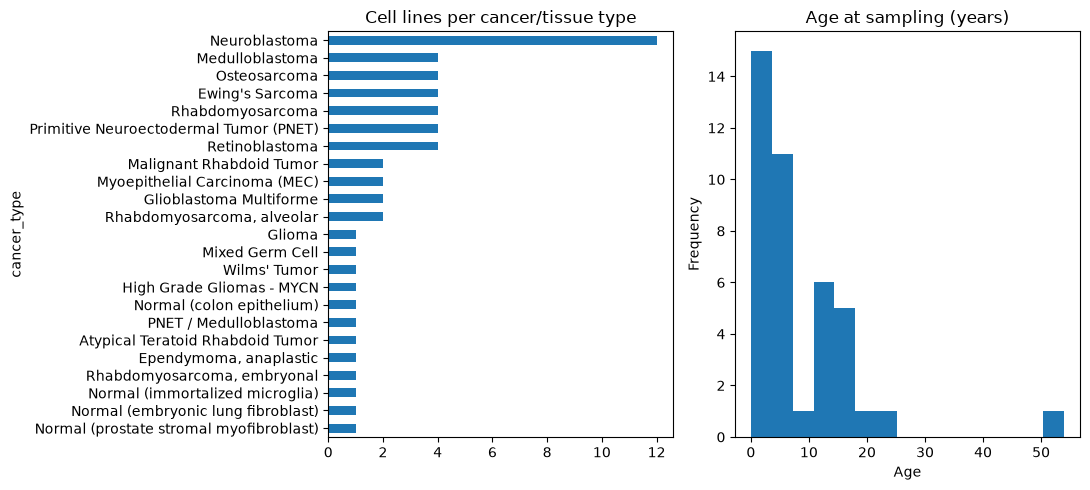

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

lines["cancer_type"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("Cell lines per cancer/tissue type")
axes[0].invert_yaxis()

lines["age"].plot(kind="hist", bins=15, ax=axes[1])
axes[1].set_title("Age at sampling (years)")
axes[1].set_xlabel("Age")

plt.tight_layout()

### 12. Save the table and the column descriptions

`pccma_cell_line_metadata_columns.txt` describes every column in the table: what it holds, where it comes from, its type,
and how many rows are empty. The notebook asserts that its column list and the table's columns match exactly, so a
column can never be added without being documented.

In [14]:
manifest_rows = [
    ("cell_line_key", "Normalized join key: the cell line name uppercased with everything except letters and digits removed (e.g. CHLA-10 -> CHLA10). Reconciles spelling differences across sheets and files.", "Derived from cell_line"),
    ("cell_line", "Cell line name as written in the 'Atlas conditions' sheet.", "Rambutan_Atlasv2_April2026.xlsx: Atlas conditions"),
    ("depmap_id", "DepMap model ID (ACH-XXXXXX). Empty for lines not in DepMap (e.g. most COG patient-derived lines, normal reference lines).", "DepMap Model.csv (downloaded 2025-12-03), matched on normalized name; PedMap where DepMap has no match"),
    ("cancer_type", "Cancer type / diagnosis. ATCC normal reference lines use their documented label; otherwise the first available of PedMap, COG list, DepMap OncotreePrimaryDisease, then documented lookups (parental line for derivatives, cureMEC).", "ATCC normal-line lookup > PedMap > COG list > DepMap > other lookups"),
    ("sex", "Sex of the patient the line was derived from (Male/Female). Empty when not recorded. The derivative lines (CHP212-1020/EV, SKNAS-1020/EV) copy their parental line's value. The ATCC normal reference lines use the sex on their ATCC page (HMC3's is unspecified, so it is empty).", "ATCC normal-line lookup > Cellosaurus > repository data sheet > PedMap > DepMap > STR Amelogenin (a Y allele means Male)"),
    ("age", "Age in years of the patient the line was derived from (in most sources, age at diagnosis). Empty when not recorded. The derivative lines (CHP212-1020/EV, SKNAS-1020/EV) copy their parental line's value. Of the ATCC normal reference lines, WPMY-1 is 54 years; CCD 841 CoN, WI-38 and HMC3 come from fetal tissue (21 weeks, 3 months and 8-10 weeks of gestation) and are recorded as age 0 because a gestational age is not an age in years.", "ATCC normal-line lookup > Cellosaurus > repository data sheet > PedMap > COG list > repository catalog table > DepMap"),
    ("subtype", "Molecular subtype (e.g. MYCN_amp, EWS_FLI, SHH subgroup). Empty when not recorded. The derivative lines (CHP212-1020/EV, SKNAS-1020/EV) copy their parental line's value.", "Cellosaurus (gene fusion) > repository data sheet > PedMap > repository catalog table (EWS/FLI1 Status) > Seattle Children's Brain Tumor Resource Lab catalog for BTRL lines"),
    ("source", "Where the cell line was obtained: repository and catalog number (e.g. ATCC CRL-1598, HSRRB IFO50356), COG, or the originating lab.", "PedMap > documented lookups > membership in the COG list (COG) > DepMap SourceDetail"),
    ("origin", "Anatomical origin of the specimen the line was derived from: the primary tumor site (Primary) or a metastasis (Metastasis). This is not the phase of disease (see phase_of_disease): a relapse or progressive-disease specimen taken at the primary site is still Primary here. Empty when not established, and for the normal reference lines. The derivative lines (CHP212-1020/EV, SKNAS-1020/EV) copy their parental line's value.", "Cellosaurus (metastatic / in situ) > repository data sheet > PedMap > repository catalog table (explicit metastasis) > DepMap PrimaryOrMetastasis > specimen type (body fluid = Metastasis; eye specimen in retinoblastoma = Primary)"),
    ("phase_of_disease", "Phase of disease when the specimen was taken, in the Childhood Cancer Repository's codes: Dx (before treatment), PD (progressive disease: relapse after chemotherapy), PD-BMT (relapse after chemotherapy and bone marrow transplantation), PD-PM (post-mortem, relapsed), P-EBR (recorded by the repository for CHLA-210; not defined on the site). Not the same as origin. Empty when no source records it, which is the case for most non-COG lines." + " The derivative lines (CHP212-1020/EV, SKNAS-1020/EV) copy their parental line's value.", "Repository catalog tables > PPTP paper (Kang 2011) Table 1 > repository Ewing panel PDF > COG list Phase of Therapy > DepMap PatientTreatmentStatus"),
    ("approx_doubling_time_observed", "Approximate doubling time observed in this lab at 5% CO2, as recorded (a number of hours, a range, or a note such as '(Improves after P3)'), without the leading 'Approx.'.", "PedMap: Doubling Time (5% CO2) (Observed)"),
    ("cell_line_link", "URL of the catalog page for the line (ATCC, HSRRB, or the Brain Tumor Resource Lab). For COG lines: the line's data-sheet PDF from the Childhood Cancer Repository when one exists, otherwise the repository disease catalog page that lists the line (a table page, not a per-line page). Empty when there is none: CHLA262 is not in the repository, the four derivative lines (CHP212-1020/EV, SKNAS-1020/EV) have no catalog page of their own, and PedMap has no link for the cureMEC lines (CF1500, X0092) or for RD, RH4 and D425.", "PedMap; Childhood Cancer Repository (cccells.org) for COG lines and the RH30 data sheet; ATCC product pages for the four normal reference lines; DSMZ catalog entry for CHP134"),
    ("media_formulation", "Growth media used to culture the line.", "Rambutan_Atlasv2_April2026.xlsx: Media"),
    ("plate_number", "Atlas plate set (1, 2 or 3). Each plate set is three physical plates, one per time point (24, 48, 72 hr), each with its own barcode.", "Rambutan_Atlasv2_April2026.xlsx: position of the table within Atlas conditions; Plate-N sheet names"),
    ("plate_conditions", "Plate coating (Standard, Synthemax or Laminin), with a note if the plate used double PFA fixation, exactly as recorded.", "Rambutan_Atlasv2_April2026.xlsx: Atlas conditions"),
    ("plate_ids", "Plate barcodes, pipe-separated, ordered by time point: 24 hr | 48 hr | 72 hr.", "Rambutan_Atlasv2_April2026.xlsx: Plate-N Xhr Metadata sheets"),
    ("wells", "Wells the cell line was seeded in, pipe-separated (row letter + two-digit column, e.g. B02). The same wells are used on every plate listed in plate_ids.", "Rambutan_Atlasv2_April2026.xlsx: Plate-N Xhr Metadata sheets"),
    ("seeding_density_24hr", "Seeding density (cells per well) for the 24 hr plate, as recorded in Atlas conditions. A few disagree with the per-well sheets; see the data-quality check in the notebook.", "Rambutan_Atlasv2_April2026.xlsx: Atlas conditions"),
    ("seeding_density_48hr", "Seeding density (cells per well) for the 48 hr plate, as recorded in Atlas conditions.", "Rambutan_Atlasv2_April2026.xlsx: Atlas conditions"),
    ("seeding_density_72hr", "Seeding density (cells per well) for the 72 hr plate, as recorded in Atlas conditions.", "Rambutan_Atlasv2_April2026.xlsx: Atlas conditions"),
    ("cell_count_at_seeding", "Cell count of the harvested stock suspension on the day of seeding, used to calculate how much stock to dilute (units not stated in the sheet; consistent with cells/mL). Specific to the seeding day of the plate (2026-05-15 for plates 1-2, 2026-05-29 for plate 3). Empty when not recorded.", "Rambutan_Atlasv2_April2026.xlsx: Cell Density P1 & P2, Plate 3 Density+PlateMap"),
    ("qc_notes", "Free-text imaging QC comments and confirmations for the line (e.g. clustering, sparse cells, suggested density changes), exactly as recorded in the workbook. This includes duplicated text (the U2-OS notes repeat '(Confirmed)') and notes such as 'was not part of 55 cell lines' (CCD 841 CoN and CHLA262).", "Rambutan_Atlasv2_April2026.xlsx: Atlas conditions"),
]
manifest = pd.DataFrame(manifest_rows, columns=["column_name", "description", "source"])

output = (
    master.assign(plate_sort=master["plate_number"].astype(int))
    .sort_values(["cell_line", "plate_sort", "plate_conditions"])
    .reset_index(drop=True)[manifest["column_name"].tolist()]
)

assert output.columns.tolist() == manifest["column_name"].tolist()
for column in output.columns:
    if not pd.api.types.is_numeric_dtype(output[column]):
        output[column] = output[column].map(clean_text)
non_ascii = [column for column in output.columns if output[column].astype(str).str.contains(r"[^\x00-\x7f]").any()]
assert not non_ascii, f"non-ASCII text in {non_ascii}"
manifest["type"] = ["number" if pd.api.types.is_numeric_dtype(output[c]) else "text" for c in manifest["column_name"]]
manifest["n_missing"] = [int(output[c].isna().sum()) for c in manifest["column_name"]]

output.to_csv("pccma_cell_line_metadata.csv", index=False)


description_lines = [
    "PCCMA cell line metadata: column descriptions",
    "",
    "Table:    pccma_cell_line_metadata.csv",
    "Built by: build_pccma_cell_line_metadata.ipynb",
    f"Rows:     {len(output)} ({output['cell_line_key'].nunique()} cell lines; a line run under several plate conditions has one row per condition)",
    f"Columns:  {output.shape[1]}",
    "",
    "Each entry gives the column name, what it holds, where it comes from, its type, and how many rows are empty.",
    "",
]
for row in manifest.itertuples():
    description_lines += [
        row.column_name,
        indent(row.description),
        indent(f"Source: {row.source}"),
        f"    Type: {row.type}; empty in {row.n_missing} of {len(output)} rows",
        "",
    ]
column_text = "\n".join(description_lines)
assert column_text.isascii()
pathlib.Path("pccma_cell_line_metadata_columns.txt").write_text(column_text)

print("Saved pccma_cell_line_metadata.csv:", output.shape, "|", output["cell_line_key"].nunique(), "cell lines")
manifest[["column_name", "type", "n_missing"]]

Saved pccma_cell_line_metadata.csv: (62, 22) | 56 cell lines


,column_name,type,n_missing
0,cell_line_key,text,0
1,cell_line,text,0
2,depmap_id,text,24
3,cancer_type,text,0
4,sex,text,13
5,age,number,15
6,subtype,text,42
7,source,text,0
8,origin,text,14
9,phase_of_disease,text,40
